# 💳 Credit Default Prediction with Logistic Regression

## Project Overview

It is 2005. A Taiwanese bank is sitting on a portfolio of 30,000 credit card accounts and needs to answer a practical question: which customers are likely to default on their payment next month?
This analysis builds and evaluates a logistic regression model to predict credit card default using demographic data, credit history, and payment behavior, then tests whether model performance holds across different time periods within the dataset.

This project was completed as part of **Analytics for Financial Markets**, a core component of the **Master of Management Analytics curriculum at Queen's University**.

## Objective and Evaluation Metric

## Objective

**Primary objective:** Predict the probability that a credit card holder will default on their next payment using demographic data, credit history, and payment behavior.

**Secondary objective:** Determine which evaluation metric best captures model performance in a credit risk context, and why accuracy alone is insufficient. To answer this, the analysis compares five metrics across two models trained on different time periods: Accuracy, Recall, Precision, F1, and AUC-ROC.

| Metric | What it measures | Business interpretation |
|--------|-----------------|------------------------|
| **Accuracy** | Overall correct predictions | Misleading with imbalanced data — a model that predicts "no default" for every customer achieves 78% accuracy while being completely useless |
| **Recall (Default)** | % of actual defaults correctly identified | Measures the cost of missing a default — a missed default means extending credit to someone who won't pay |
| **Precision (Default)** | % of predicted defaults that are actual defaults | Measures the cost of false alarms — low precision means rejecting solvable customers who would have paid |
| **F1 (Default)** | Balance between Recall and Precision | Useful when both missing defaults and false alarms have meaningful business costs |
| **AUC-ROC** | Model's ability to discriminate between defaulters and non-defaulters across all thresholds | Overall ranking ability — independent of any specific classification cutoff |

## Analytical Competencies Demonstrated

1. Exploratory Data Analysis (EDA) — distribution analysis, correlation matrix, outlier detection
2. Data preprocessing — IQR-based outlier capping, one-hot encoding of categorical variables, feature scaling, and evidence-based transformation decisions (log1p evaluation on LIMIT_BAL)
3. Class imbalance handling — `class_weight='balanced'` to address skewed target distribution
4. Logistic regression modeling — binary classification with interpretable coefficients
5. Model evaluation — confusion matrix, classification report, Accuracy, Recall, Precision, F1, and AUC-ROC across two temporal splits
6. Temporal validation — comparing model performance across two different train/test splits to detect data drift

## Dataset Characteristics

| Parameter | Details |
|-----------|---------|
| **Source** | Adapted from the UCI Machine Learning Repository — Default of Credit Card Clients Dataset (Yeh, I.C., 2009), with modifications by course instructor. Original dataset available at: https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients |
| **Observations** | 30,000 credit card holders |
| **Target variable** | `default.payment.next.month` (1 = default, 0 = no default) |
| **Class distribution** | ~78% no default, ~22% default |
| **Features** | 23 variables including demographic info, credit limit, payment history, and bill amounts |

**Key feature groups:**

| Group | Variables |
|-------|-----------|
| Demographics | SEX, EDUCATION, MARRIAGE, AGE |
| Credit profile | LIMIT_BAL (credit limit assigned to each customer) |
| Payment status | PAY_1 to PAY_6 (monthly repayment status) |
| Bill amounts | BILL_AMT1 to BILL_AMT6 (monthly statement balances) |
| Payment amounts | PAY_AMT1 to PAY_AMT6 (actual payments made) |

## Analytical Framework

| Method | Purpose |
|--------|---------|
| **IQR Outlier Capping** | Cap extreme values in continuous variables without removing rows |
| **One-Hot Encoding** | Treat SEX, EDUCATION, and MARRIAGE as nominal categories, not ordered values |
| **StandardScaler** | Normalize continuous variables to the same scale before modeling |
| **Logistic Regression** | Predict probability of default; produces interpretable coefficients |
| **class_weight='balanced'** | Adjust loss function to penalize missed defaults more heavily |
| **AUC-ROC** | Evaluate discrimination power independent of classification threshold |
| **Temporal split comparison** | Train on different time windows to detect shifts in feature importance |

## Core Libraries

| Library | Application |
|---------|-------------|
| `pandas` | Data manipulation and preprocessing |
| `numpy` | Numerical operations, outlier bounds |
| `matplotlib` / `seaborn` | EDA visualizations, confusion matrix, ROC curve |
| `sklearn.linear_model` | Logistic regression model |
| `sklearn.preprocessing` | StandardScaler for feature normalization |
| `sklearn.metrics` | Accuracy, classification report, AUC-ROC, ROC curve display |

## 1. Environment Setup & Library Imports

The dataset contains 30,000 credit card accounts from a Taiwanese bank, with demographic information, credit limits, payment history, and bill amounts for each customer. The target variable indicates whether each customer defaulted on their payment the following month.

In [32]:
# ============================================================
# Imports and Data Loading
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, RocCurveDisplay)
import warnings
warnings.filterwarnings('ignore')

# Load the data
df = pd.read_csv('Credit Card Data (1).csv')

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())


Dataset Shape: (30000, 31)

First few rows:
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.next.month  \
0  ...       0.0       0.0       0.0                           1   
1  ...    1000.0       0.0    2000.0                           1   
2  ...    1000.0    1000.0    5000.0                           0   
3  ...    1100.0    1069.0    1000.0                           0   
4  ...    9000.0     689.0     679.0                           0   

   Education_Level1  Education_Level2  Education_Level3  Marital_Status1

## 2. Missing values and class distribution

Before any preprocessing or modeling, two questions need to be answered: are there missing values that require treatment? And how balanced is the target variable? The second question is particularly critical in credit risk, if defaults are rare relative to non-defaults, standard evaluation metrics like accuracy become misleading and the model requires special handling during training.

In [33]:
# ============================================================
# Missing values and class distribution
# ============================================================
print("Missing values in each column:")
print(df.isnull().sum())

print("\nTarget variable distribution:")
print(df['default.payment.next.month'].value_counts())
print(df['default.payment.next.month'].value_counts(normalize=True))

Missing values in each column:
ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
Education_Level1              0
Education_Level2              0
Education_Level3              0
Marital_Status1               0
Marital_Status2               0
Marital_S

### Key Observations

The dataset has no missing values across any of the 31 columns, therefore no imputation strategy is required. The target variable is imbalanced: 77.88% of customers did not default vs 22.12% who did, at roughly a 4:1 ratio. This directly motivates the use of `class_weight='balanced'` during training and the comparison of multiple evaluation metrics beyond accuracy.

## 3. Categorical variables check

Before modeling, it is important to verify the actual values present in SEX, EDUCATION, and MARRIAGE. This confirms whether the data matches the documented categories and informs the one-hot encoding strategy applied in the preprocessing step.

In [34]:
# ============================================================
# Categorical variables check
# ============================================================
categorical_cols = ['SEX', 'EDUCATION', 'MARRIAGE', 'Education_Level1', 'Education_Level2',
                   'Education_Level3', 'Marital_Status1', 'Marital_Status2', 'Marital_Status3']

print("Categorical variables value counts:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

Categorical variables value counts:

SEX:
SEX
2    18112
1    11888
Name: count, dtype: int64

EDUCATION:
EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

MARRIAGE:
MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

Education_Level1:
Education_Level1
0    19415
1    10585
Name: count, dtype: int64

Education_Level2:
Education_Level2
0    15970
1    14030
Name: count, dtype: int64

Education_Level3:
Education_Level3
0    25083
1     4917
Name: count, dtype: int64

Marital_Status1:
Marital_Status1
0    16341
1    13659
Name: count, dtype: int64

Marital_Status2:
Marital_Status2
1    15964
0    14036
Name: count, dtype: int64

Marital_Status3:
Marital_Status3
0    29677
1      323
Name: count, dtype: int64


### Key Observations

SEX skews female (60.4%). EDUCATION is concentrated in university (46.8%) and graduate school (35.3%) holders. MARRIAGE is split between married (53.2%) and single (45.5%) customers. Notably, EDUCATION contains undocumented values (0, 5, 6) representing 1.2% of observations, these will be treated as additional nominal groups during one-hot encoding rather than removed.

## 4. EDA visualizations

The visualizations below examine the distribution of the target variable and four demographic variables (AGE, SEX, EDUCATION, and MARRIAGE) alongside credit limit (LIMIT_BAL). The goal is to understand the composition of the dataset before any modeling decisions are made, identifying imbalances or unusual patterns that may require special treatment during preprocessing.

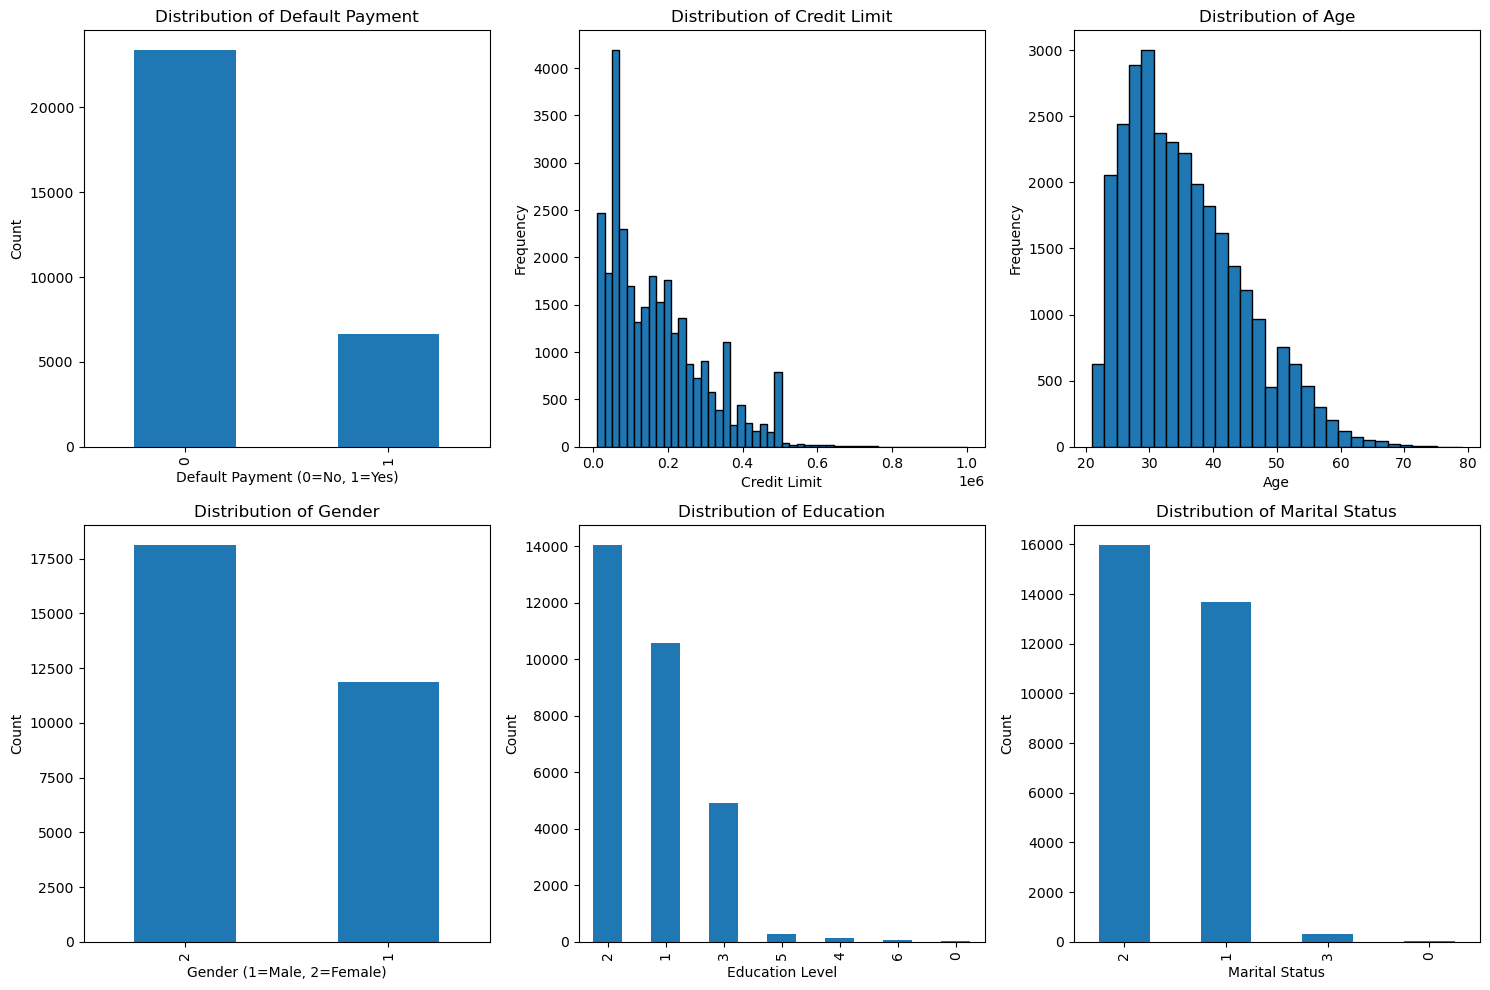

In [35]:
# ============================================================
# EDA visualizations
# ============================================================
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
df['default.payment.next.month'].value_counts().plot(kind='bar')
plt.title('Distribution of Default Payment')
plt.xlabel('Default Payment (0=No, 1=Yes)')
plt.ylabel('Count')

plt.subplot(2, 3, 2)
plt.hist(df['LIMIT_BAL'], bins=50, edgecolor='black')
plt.title('Distribution of Credit Limit')
plt.xlabel('Credit Limit')
plt.ylabel('Frequency')

plt.subplot(2, 3, 3)
plt.hist(df['AGE'], bins=30, edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.subplot(2, 3, 4)
df['SEX'].value_counts().plot(kind='bar')
plt.title('Distribution of Gender')
plt.xlabel('Gender (1=Male, 2=Female)')
plt.ylabel('Count')

plt.subplot(2, 3, 5)
df['EDUCATION'].value_counts().plot(kind='bar')
plt.title('Distribution of Education')
plt.xlabel('Education Level')
plt.ylabel('Count')

plt.subplot(2, 3, 6)
df['MARRIAGE'].value_counts().plot(kind='bar')
plt.title('Distribution of Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


### Key Observations

LIMIT_BAL shows a right-skewed distribution with a long upper tail, a small number of customers hold significantly higher credit limits than the majority, consistent with real-world credit portfolios.

## 5. Correlation matrix and boxplots

Two complementary analyses are run here. First, the correlation matrix reveals how strongly each variable moves together with the target and with other features, helping identify which variables are most linearly associated with default risk and whether any predictors are highly collinear with each other.

Second, boxplots for the key numerical variables expose the presence and magnitude of outliers in bill amounts and payment amounts. This visual inspection directly informs the outlier capping strategy applied in the next step.

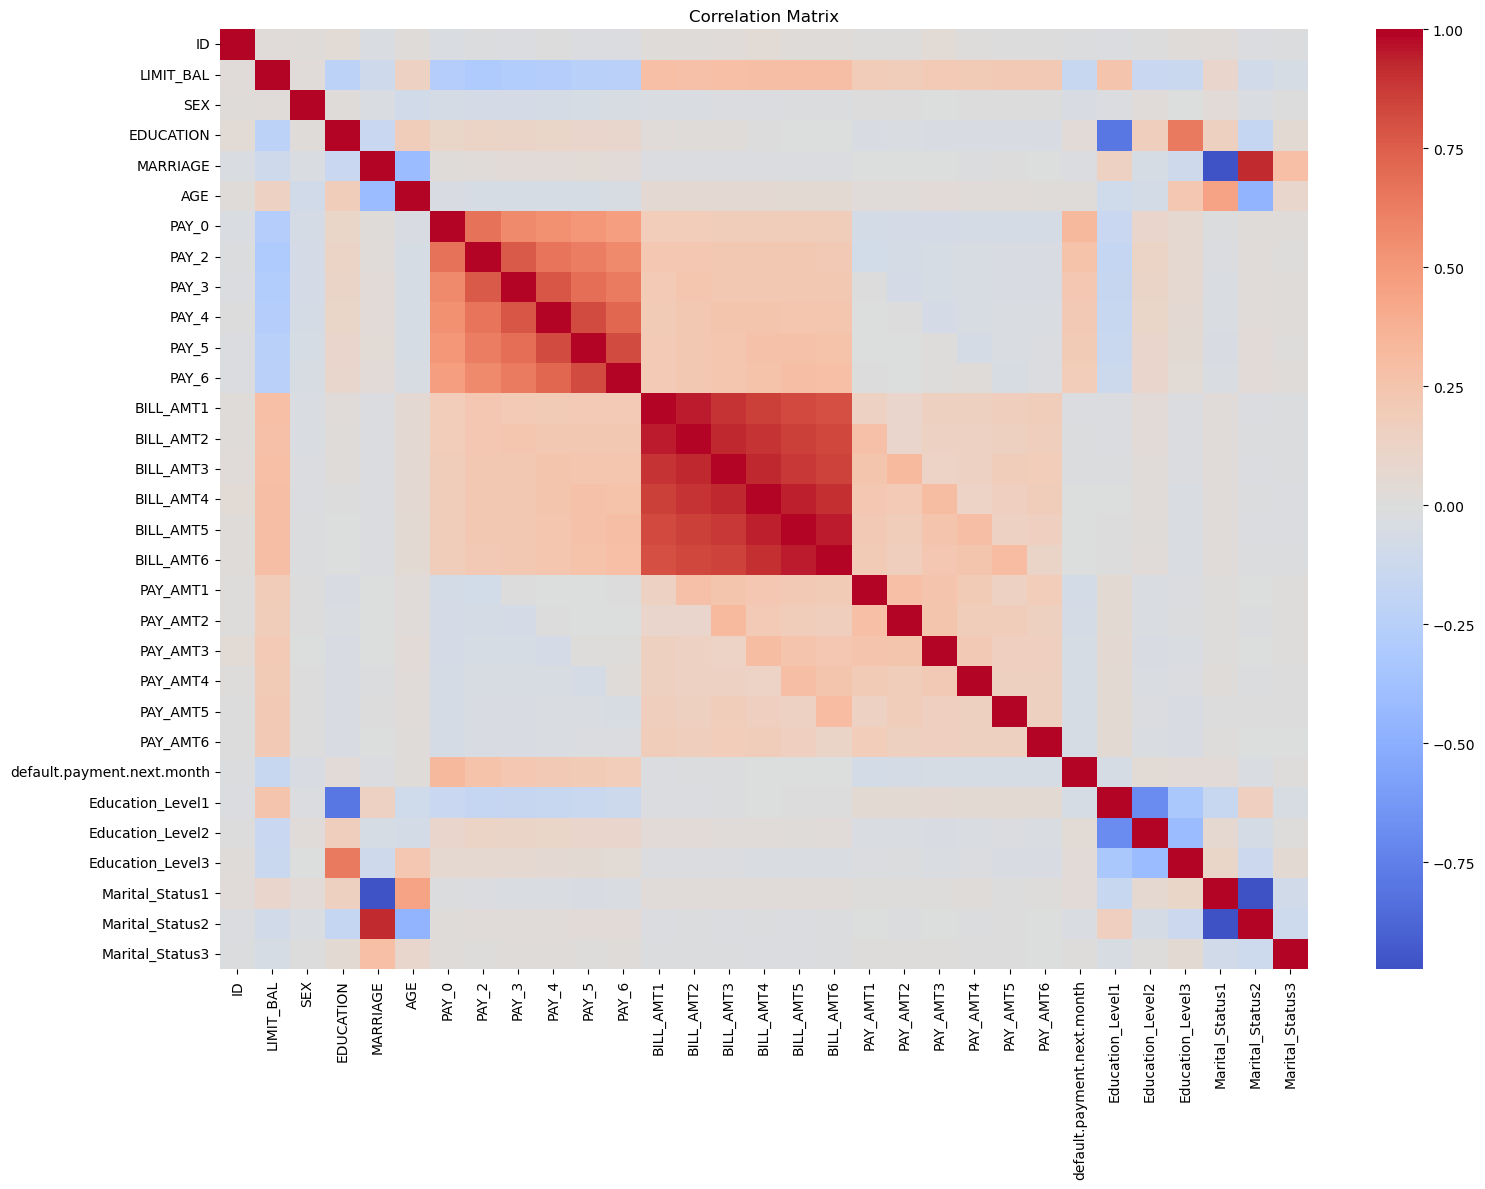

Correlation with target variable (default.payment.next.month):
default.payment.next.month    1.000000
PAY_0                         0.324794
PAY_2                         0.263551
PAY_3                         0.235253
PAY_4                         0.216614
PAY_5                         0.204149
PAY_6                         0.186866
Education_Level2              0.036467
Education_Level3              0.032403
Marital_Status1               0.029775
EDUCATION                     0.028006
AGE                           0.013890
Marital_Status3               0.009768
BILL_AMT6                    -0.005372
BILL_AMT5                    -0.006760
BILL_AMT4                    -0.010156
ID                           -0.013952
BILL_AMT3                    -0.014076
BILL_AMT2                    -0.014193
BILL_AMT1                    -0.019644
MARRIAGE                     -0.024339
Marital_Status2              -0.030619
SEX                          -0.039961
Education_Level1             -0.051328
P

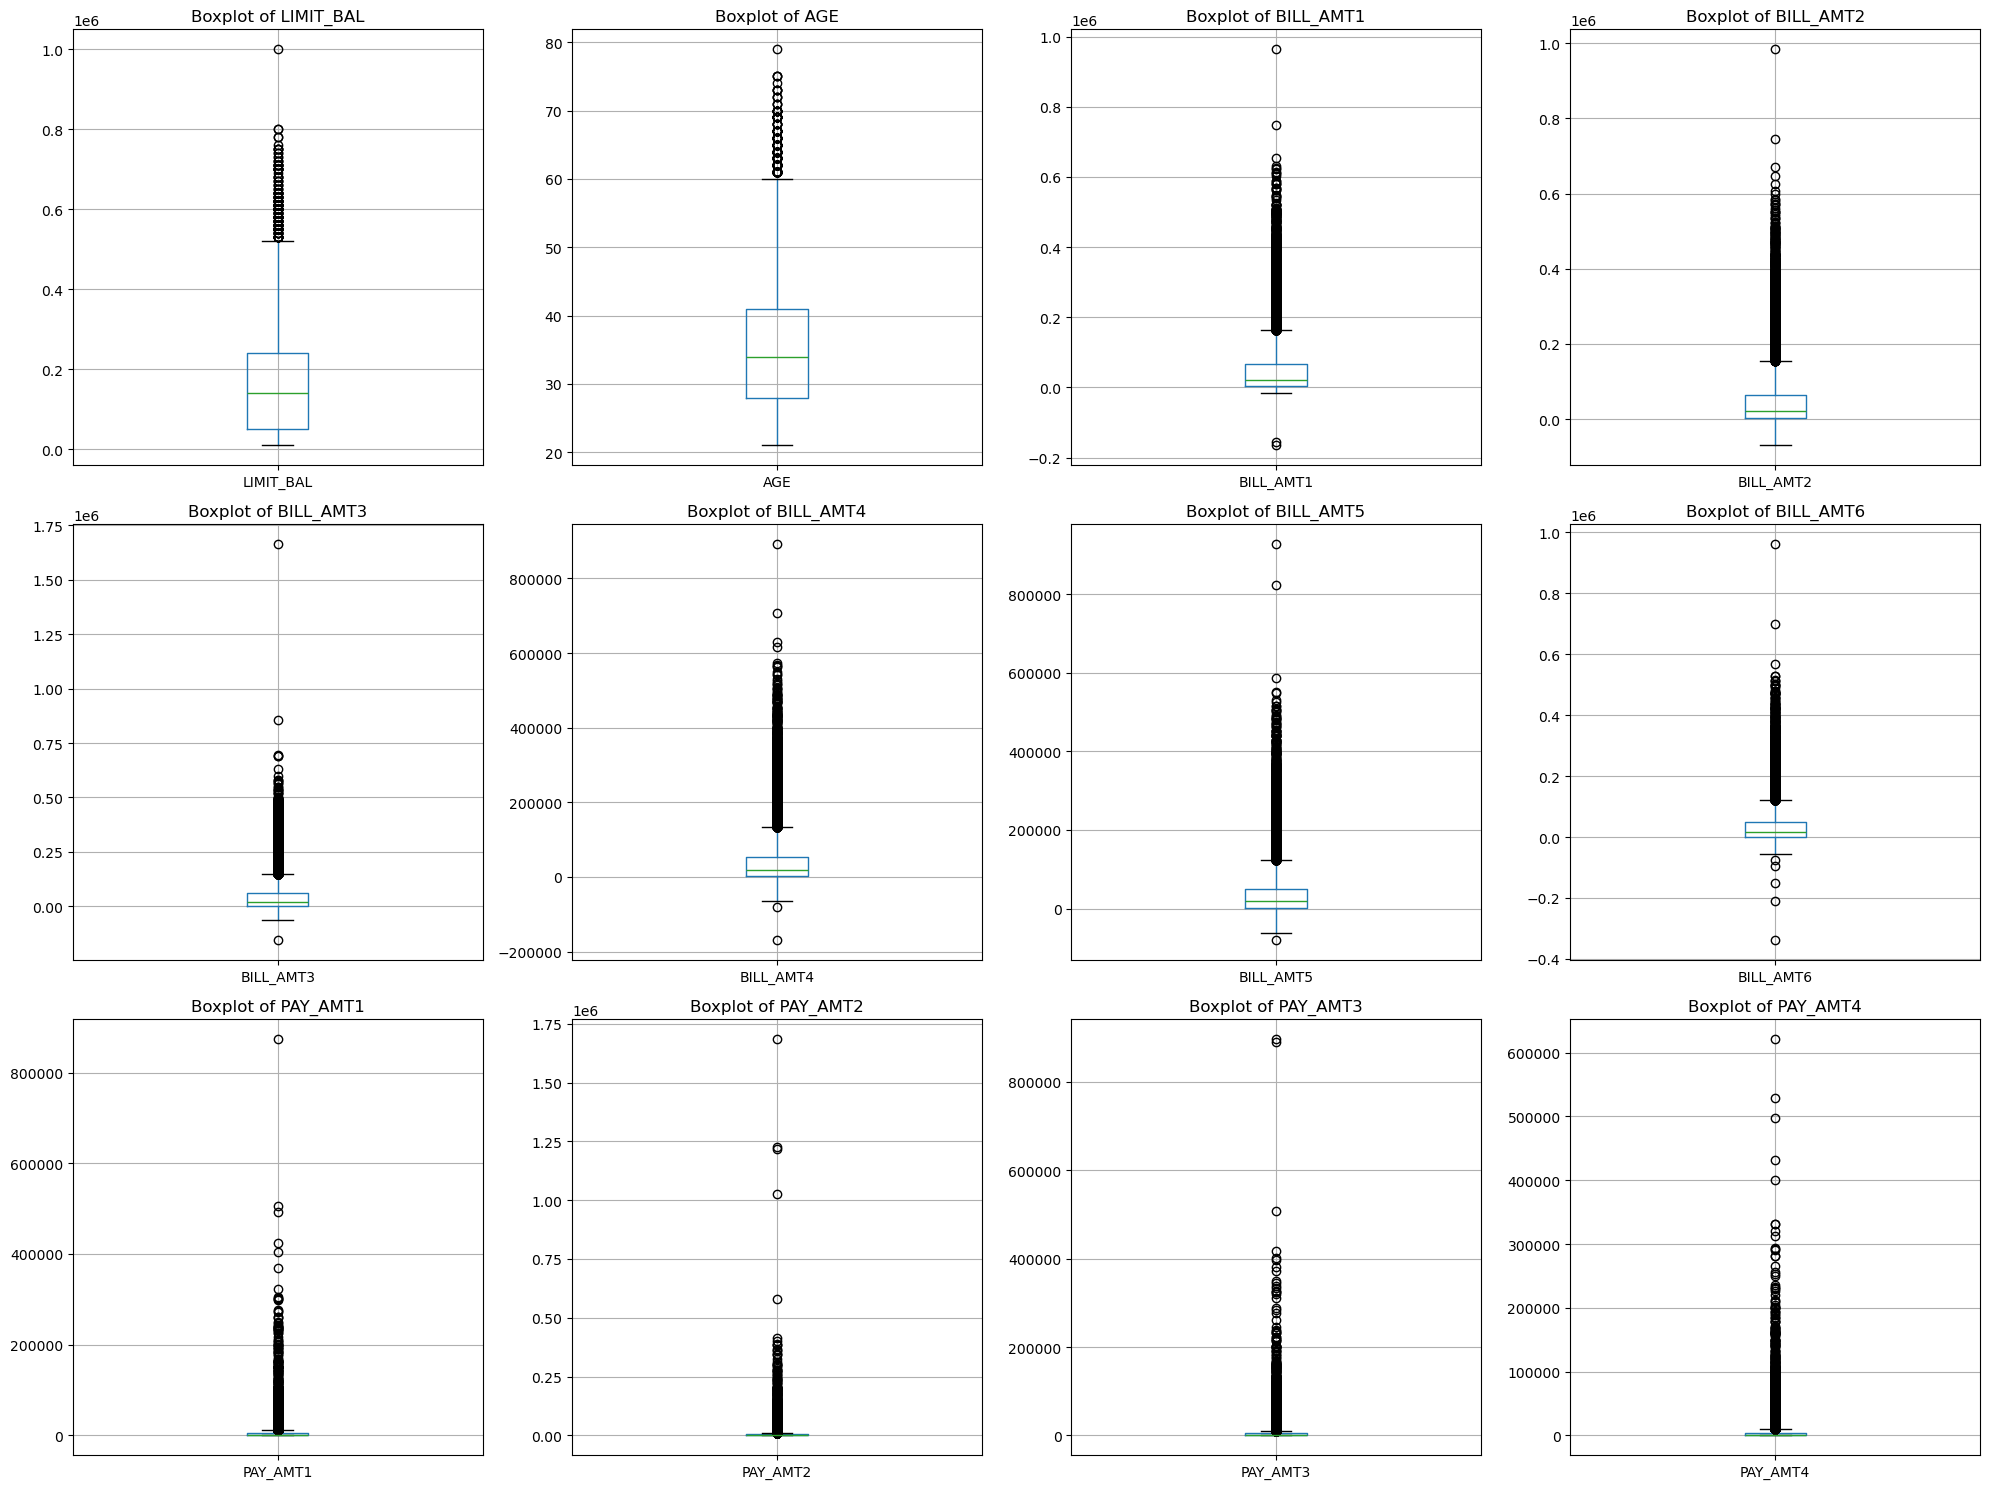

In [36]:
# ============================================================
# Correlation matrix and boxplots
# ============================================================
plt.figure(figsize=(16, 12))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

target_corr = correlation_matrix['default.payment.next.month'].sort_values(ascending=False)
print("Correlation with target variable (default.payment.next.month):")
print(target_corr)

numerical_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
                 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2',
                 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_cols[:12], 1):
    plt.subplot(3, 4, i)
    df.boxplot(column=col)
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

### Key Observations

**Strongest predictors of default — Payment status variables:**
PAY_0 through PAY_6 form a clearly visible red block in the correlation matrix, showing the strongest positive associations with default. PAY_0 leads at 0.325, with signal weakening progressively for older months. A customer already behind on payments is the single strongest indicator of future default.

**High internal correlation within feature groups:**
The matrix reveals three distinct correlation clusters:
- PAY_0 to PAY_6 are highly correlated with each other: payment behavior tends to be consistent across months
- BILL_AMT1 to BILL_AMT6 form a tight cluster of high mutual correlation: monthly balances move together, suggesting limited additional information from including all six
- PAY_AMT1 to PAY_AMT6 show moderate internal correlation

**Credit limit as a protective factor:**
LIMIT_BAL shows the strongest negative correlation with default (-0.154) and is visually distinct in the heatmap. Higher limits are assigned to lower-risk customers, so this directional relationship is expected.

**Bill amounts are nearly uncorrelated with default:**
Despite forming a strong internal cluster, BILL_AMT1 to BILL_AMT6 show near-zero correlation with the target (all below -0.02). Outstanding balance size alone does not predict default, what matters is whether the customer is actually making payments.

**Demographic variables have minimal linear association:**
SEX, EDUCATION, MARRIAGE, and AGE all show very weak correlations with default, visible as near-white cells in the heatmap. This does not make them irrelevant, but they are not strong standalone predictors.

**Boxplots — Outlier severity:**
The boxplots confirm significant outliers across all numerical variables:
- **LIMIT_BAL:** Long upper tail extending to 1M, with the interquartile range concentrated well below 250K
- **BILL_AMT1 to BILL_AMT6:** Extreme positive outliers reaching up to $1.75M, with some negative values visible, likely reflecting credit balances or adjustments. The IQR is compressed near zero relative to the outlier range
- **PAY_AMT1 to PAY_AMT4:** Majority of payments cluster near zero with extreme outliers reaching 800K–1.75M, reflecting a small number of customers making very large payments
- **AGE:** Relatively mild outliers compared to financial variables, with a few observations above 70

The severity of outliers in BILL_AMT and PAY_AMT variables makes IQR capping essential before modeling. Without it, a handful of extreme observations could disproportionately influence the logistic regression coefficients.

## 6. Preprocessing: Outlier Handling and Feature Encoding

With the distribution and outlier patterns identified in the previous step, two preprocessing decisions are applied before modeling.

**Outlier capping (IQR method):** Extreme values in BILL_AMT and PAY_AMT variables are capped at 1.5 × IQR above Q3 and below Q1. Values beyond these limits are replaced by the limit itself — preserving all 30,000 rows while preventing extreme observations from disproportionately influencing the model coefficients.

**One-hot encoding:** SEX, EDUCATION, and MARRIAGE are converted from numeric codes into binary dummy variables. Treating them as numbers would imply a false ordering,for example, EDUCATION=3 is not "three times more educated" than EDUCATION=1. One-hot encoding treats each category as an independent group, which is the correct representation for nominal variables.

In [37]:
# ============================================================
# Outlier handling + ONE-HOT ENCODING
# ============================================================
def handle_outliers(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_clean[col] = np.where(df_clean[col] < lower_bound, lower_bound, df_clean[col])
        df_clean[col] = np.where(df_clean[col] > upper_bound, upper_bound, df_clean[col])
    return df_clean

# Handle outliers in numerical columns
df_clean = handle_outliers(df, numerical_cols)

# ---One-hot encode categorical variables ---
# SEX, EDUCATION, and MARRIAGE are nominal categories, not ordinal values.
# Treating them as numeric codes would imply a false ranking (e.g., EDUCATION=3
# is not "three times more educated" than EDUCATION=1).
# One-hot encoding treats each category as an independent binary feature.
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
df_clean = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

# Drop ID and pre-existing one-hot columns from original dataset
features_to_drop = ['ID', 'Education_Level1', 'Education_Level2', 'Education_Level3',
                   'Marital_Status1', 'Marital_Status2', 'Marital_Status3']

X = df_clean.drop(features_to_drop + ['default.payment.next.month'], axis=1)
y = df_clean['default.payment.next.month']

print("Feature columns after one-hot encoding:", X.columns.tolist())
print("Shape of X:", X.shape)

# --- Address class imbalance ---
# The dataset is imbalanced (~78% non-default, ~22% default).
# In credit risk, failing to detect a default (false negative) is far more costly
# than a false alarm. class_weight='balanced' adjusts the loss function to
# penalize misclassification of the minority class (defaults) more heavily.
print("\nClass distribution in target:")
print(y.value_counts(normalize=True))

Feature columns after one-hot encoding: ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'SEX_2', 'EDUCATION_1', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'EDUCATION_5', 'EDUCATION_6', 'MARRIAGE_1', 'MARRIAGE_2', 'MARRIAGE_3']
Shape of X: (30000, 30)

Class distribution in target:
default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


## 7. Preprocessing Decision: LIMIT_BAL Log Transformation

LIMIT_BAL shows a right-skewed distribution spanning two orders of magnitude (10,000 to 1,000,000), which in theory justifies a log1p transformation to compress the upper tail and create a more linear relationship with the target.

To validate whether this transformation actually improves model performance, both versions (with and without log1p) are trained and evaluated across all five metrics. The simpler pipeline is preferred unless the improvement in AUC-ROC exceeds 0.005.

In [38]:
# ============================================================
# LIMIT_BAL LOG TRANSFORM COMPARISON
# Run both versions and compare metrics to decide whether
# log1p transformation improves model performance enough
# to justify the added complexity.
# ============================================================

from sklearn.metrics import (accuracy_score, recall_score,
                             precision_score, f1_score, roc_auc_score)

def evaluate_model(model, X_test, y_test, y_prob, model_name):
    """Return a dict of evaluation metrics for a given model."""
    y_pred = model.predict(X_test)
    return {
        'Model': model_name,
        'Accuracy':           round(accuracy_score(y_test, y_pred), 4),
        'Recall (Default)':   round(recall_score(y_test, y_pred), 4),
        'Precision (Default)':round(precision_score(y_test, y_pred), 4),
        'F1 (Default)':       round(f1_score(y_test, y_pred), 4),
        'AUC-ROC':            round(roc_auc_score(y_test, y_prob), 4),
    }

# ============================================================
# VERSION A — Without log1p (baseline, current model)
# ============================================================
df_baseline = handle_outliers(df, numerical_cols)
df_baseline = pd.get_dummies(df_baseline, columns=cat_cols, drop_first=True)


X_base = df_baseline.drop(features_to_drop + ['default.payment.next.month'], axis=1)
y_base = df_baseline['default.payment.next.month']

# Split — Model 1 (First 20K / Next 10K)
X_train_b1, X_test_b1 = X_base.iloc[:20000], X_base.iloc[20000:30000]
y_train_b1, y_test_b1 = y_base.iloc[:20000], y_base.iloc[20000:30000]

numerical_cols_for_scaling = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
                              'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2',
                              'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

scaler_b = StandardScaler()
X_train_b1_scaled = X_train_b1.copy()
X_test_b1_scaled = X_test_b1.copy()
X_train_b1_scaled[numerical_cols_for_scaling] = scaler_b.fit_transform(X_train_b1[numerical_cols_for_scaling])
X_test_b1_scaled[numerical_cols_for_scaling] = scaler_b.transform(X_test_b1[numerical_cols_for_scaling])

model_b1 = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model_b1.fit(X_train_b1_scaled, y_train_b1)
prob_b1 = model_b1.predict_proba(X_test_b1_scaled)[:, 1]

# Split — Model 2 (Last 20K / First 10K)
X_train_b2, X_test_b2 = X_base.iloc[-20000:], X_base.iloc[:10000]
y_train_b2, y_test_b2 = y_base.iloc[-20000:], y_base.iloc[:10000]

scaler_b2 = StandardScaler()
X_train_b2_scaled = X_train_b2.copy()
X_test_b2_scaled = X_test_b2.copy()
X_train_b2_scaled[numerical_cols_for_scaling] = scaler_b2.fit_transform(X_train_b2[numerical_cols_for_scaling])
X_test_b2_scaled[numerical_cols_for_scaling] = scaler_b2.transform(X_test_b2[numerical_cols_for_scaling])

model_b2 = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model_b2.fit(X_train_b2_scaled, y_train_b2)
prob_b2 = model_b2.predict_proba(X_test_b2_scaled)[:, 1]


# ============================================================
# VERSION B — With log1p on LIMIT_BAL
# ============================================================
df_log = handle_outliers(df, numerical_cols)

# Apply log1p to LIMIT_BAL before one-hot encoding
# Rationale: LIMIT_BAL spans $10K–$1M (two orders of magnitude),
# suggesting a multiplicative relationship with credit risk.
# log1p compresses the right tail without risk of log(0) errors.
df_log['LIMIT_BAL'] = np.log1p(df_log['LIMIT_BAL'])

df_log = pd.get_dummies(df_log, columns=cat_cols, drop_first=True)

X_log = df_log.drop(features_to_drop + ['default.payment.next.month'], axis=1)
y_log = df_log['default.payment.next.month']

# Split — Model 1
X_train_l1, X_test_l1 = X_log.iloc[:20000], X_log.iloc[20000:30000]
y_train_l1, y_test_l1 = y_log.iloc[:20000], y_log.iloc[20000:30000]

scaler_l = StandardScaler()
X_train_l1_scaled = X_train_l1.copy()
X_test_l1_scaled = X_test_l1.copy()
X_train_l1_scaled[numerical_cols_for_scaling] = scaler_l.fit_transform(X_train_l1[numerical_cols_for_scaling])
X_test_l1_scaled[numerical_cols_for_scaling] = scaler_l.transform(X_test_l1[numerical_cols_for_scaling])

model_l1 = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model_l1.fit(X_train_l1_scaled, y_train_l1)
prob_l1 = model_l1.predict_proba(X_test_l1_scaled)[:, 1]

# Split — Model 2
X_train_l2, X_test_l2 = X_log.iloc[-20000:], X_log.iloc[:10000]
y_train_l2, y_test_l2 = y_log.iloc[-20000:], y_log.iloc[:10000]

scaler_l2 = StandardScaler()
X_train_l2_scaled = X_train_l2.copy()
X_test_l2_scaled = X_test_l2.copy()
X_train_l2_scaled[numerical_cols_for_scaling] = scaler_l2.fit_transform(X_train_l2[numerical_cols_for_scaling])
X_test_l2_scaled[numerical_cols_for_scaling] = scaler_l2.transform(X_test_l2[numerical_cols_for_scaling])

model_l2 = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model_l2.fit(X_train_l2_scaled, y_train_l2)
prob_l2 = model_l2.predict_proba(X_test_l2_scaled)[:, 1]


# ============================================================
# COMPARISON TABLE
# ============================================================
results = pd.DataFrame([
    evaluate_model(model_b1, X_test_b1_scaled, y_test_b1, prob_b1,
                   'Model 1 — No log1p (First 20K / Next 10K)'),
    evaluate_model(model_b2, X_test_b2_scaled, y_test_b2, prob_b2,
                   'Model 2 — No log1p (Last 20K / First 10K)'),
    evaluate_model(model_l1, X_test_l1_scaled, y_test_l1, prob_l1,
                   'Model 1 — With log1p (First 20K / Next 10K)'),
    evaluate_model(model_l2, X_test_l2_scaled, y_test_l2, prob_l2,
                   'Model 2 — With log1p (Last 20K / First 10K)'),
])

print("=" * 70)
print("LIMIT_BAL LOG TRANSFORM — IMPACT ON MODEL PERFORMANCE")
print("=" * 70)
print(results.to_string(index=False))
print()
print("Decision rule:")
print("  If AUC-ROC improves by >= 0.005 → apply log1p (meaningful improvement)")
print("  If AUC-ROC improves by  < 0.005 → keep baseline (simpler is better)")

LIMIT_BAL LOG TRANSFORM — IMPACT ON MODEL PERFORMANCE
                                      Model  Accuracy  Recall (Default)  Precision (Default)  F1 (Default)  AUC-ROC
  Model 1 — No log1p (First 20K / Next 10K)    0.7104            0.6261               0.3804        0.4733   0.7365
  Model 2 — No log1p (Last 20K / First 10K)    0.6575            0.6459               0.3572        0.4600   0.7182
Model 1 — With log1p (First 20K / Next 10K)    0.7104            0.6314               0.3812        0.4754   0.7373
Model 2 — With log1p (Last 20K / First 10K)    0.6570            0.6481               0.3572        0.4605   0.7185

Decision rule:
  If AUC-ROC improves by >= 0.005 → apply log1p (meaningful improvement)
  If AUC-ROC improves by  < 0.005 → keep baseline (simpler is better)


### Key Observations

| Version | AUC-ROC Model 1 | AUC-ROC Model 2 |
|---------|----------------|----------------|
| Without log1p | 0.7365 | 0.7182 |
| With log1p | 0.7373 | 0.7185 |
| Difference | +0.0008 | +0.0003 |

The improvement falls well below the 0.005 threshold considered meaningful. 
StandardScaler combined with IQR capping is sufficient to handle the skewness. 

**The simpler pipeline without log1p was selected for the final model.**

## 8. Model Training

With preprocessing complete, the logistic regression model is trained and evaluated using two different train-test splits. This approach tests whether model performance is consistent across different time periods within the dataset, or whether the 
underlying relationship between features and default risk shifts over time.

### Model 1: First 20K train / Next 10K test

**Split 1:** First 20,000 rows for training, next 10,000 for testing. This follows the natural chronological order of the data, the model learns from earlier accounts and is tested on more recent ones.

The model is trained with `class_weight='balanced'` to account for the 4:1 class imbalance identified earlier. Performance is evaluated across five metrics: Accuracy, Recall, Precision, F1, and AUC-ROC.

Training set size: (20000, 30)
Test set size: (10000, 30)

Model 1 Accuracy: 0.7104
Model 1 AUC-ROC:  0.7365

Classification Report (focus on class 1 — defaults):
              precision    recall  f1-score   support

  No Default       0.88      0.73      0.80      7922
     Default       0.38      0.63      0.47      2078

    accuracy                           0.71     10000
   macro avg       0.63      0.68      0.64     10000
weighted avg       0.78      0.71      0.73     10000



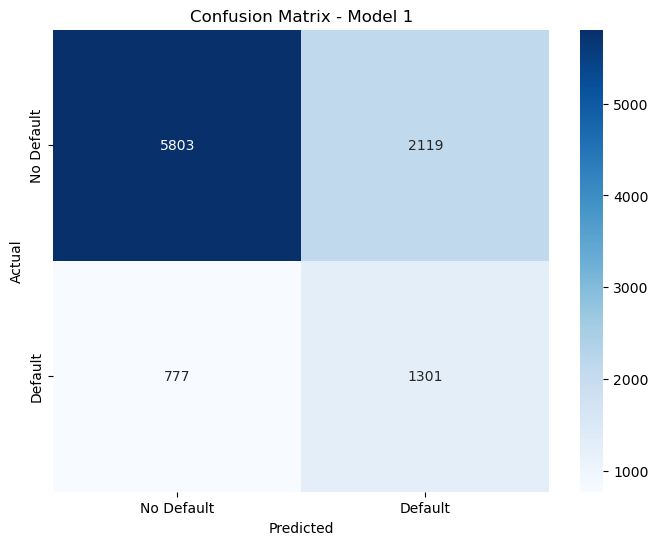

<Figure size 800x600 with 0 Axes>

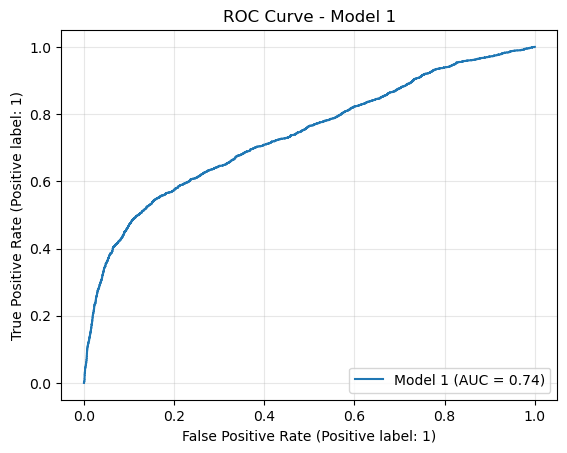

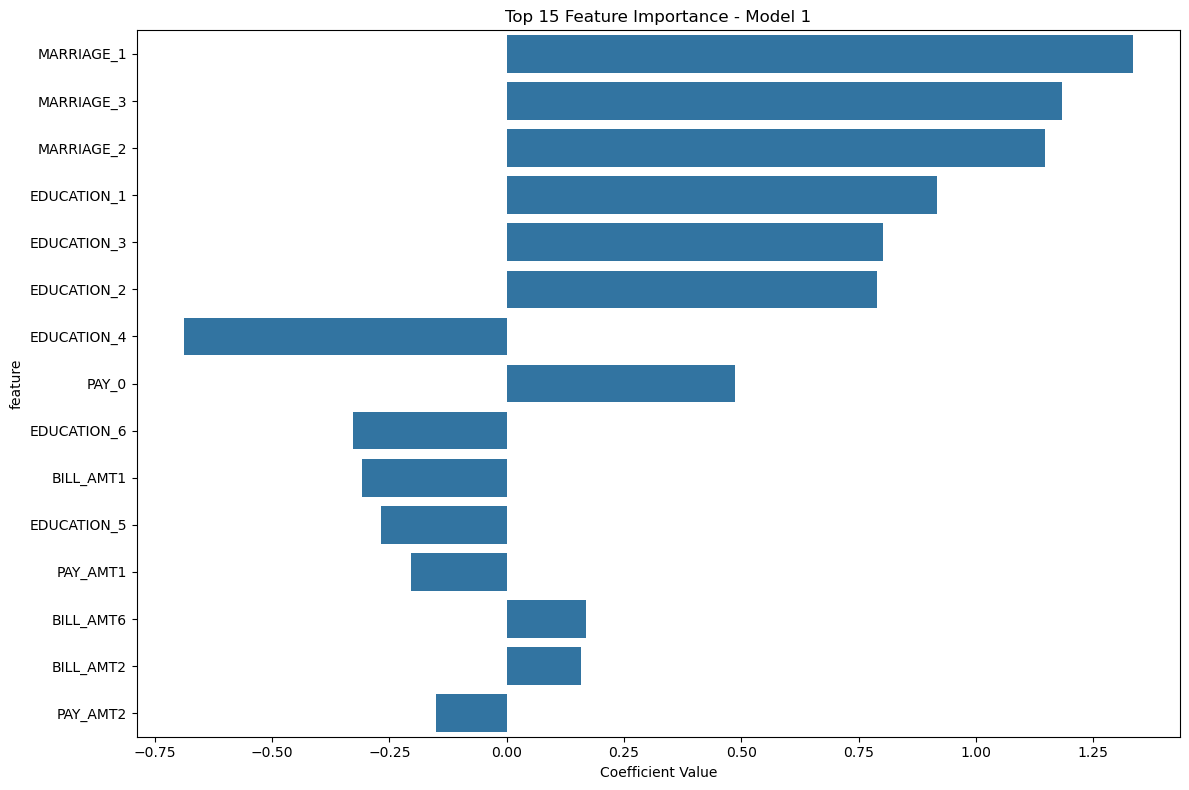

Top 15 Most Important Features:
        feature  importance
27   MARRIAGE_1    1.333483
29   MARRIAGE_3    1.183256
28   MARRIAGE_2    1.147239
21  EDUCATION_1    0.916085
23  EDUCATION_3    0.802260
22  EDUCATION_2    0.787946
24  EDUCATION_4   -0.686816
2         PAY_0    0.486847
26  EDUCATION_6   -0.327316
8     BILL_AMT1   -0.308430
25  EDUCATION_5   -0.268711
14     PAY_AMT1   -0.203680
13    BILL_AMT6    0.169974
9     BILL_AMT2    0.159350
15     PAY_AMT2   -0.150987


In [39]:
# ============================================================
# Model 1: First 20K train / Next 10K test
# ============================================================
X_train_1 = X.iloc[:20000]
y_train_1 = y.iloc[:20000]
X_test_1 = X.iloc[20000:30000]
y_test_1 = y.iloc[20000:30000]

print(f"Training set size: {X_train_1.shape}")
print(f"Test set size: {X_test_1.shape}")

# Update numerical columns list to exclude one-hot encoded columns
numerical_cols_for_scaling = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
                            'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2',
                            'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

scaler = StandardScaler()
X_train_1_scaled = X_train_1.copy()
X_test_1_scaled = X_test_1.copy()
X_train_1_scaled[numerical_cols_for_scaling] = scaler.fit_transform(X_train_1[numerical_cols_for_scaling])
X_test_1_scaled[numerical_cols_for_scaling] = scaler.transform(X_test_1[numerical_cols_for_scaling])

# Train with class_weight='balanced' to address class imbalance
logit_model_1 = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
logit_model_1.fit(X_train_1_scaled, y_train_1)

y_pred_1 = logit_model_1.predict(X_test_1_scaled)
y_prob_1 = logit_model_1.predict_proba(X_test_1_scaled)[:, 1]

# --- CORRECTION 3: Expanded evaluation metrics ---
# Accuracy alone is misleading for imbalanced datasets.
# In credit risk, recall for the default class (class 1) is the critical metric:
# a missed default (false negative) has much higher cost than a false alarm.
print(f"\nModel 1 Accuracy: {accuracy_score(y_test_1, y_pred_1):.4f}")
print(f"Model 1 AUC-ROC:  {roc_auc_score(y_test_1, y_prob_1):.4f}")
print("\nClassification Report (focus on class 1 — defaults):")
print(classification_report(y_test_1, y_pred_1, target_names=['No Default', 'Default']))

# Confusion Matrix
cm_1 = confusion_matrix(y_test_1, y_pred_1)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix - Model 1')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ROC Curve
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test_1, y_prob_1, name="Model 1")
plt.title('ROC Curve - Model 1')
plt.grid(True, alpha=0.3)
plt.show ()

# ============================================================
# Feature Importance Model 1
# ============================================================
feature_importance_1 = pd.DataFrame({
    'feature': X.columns,
    'importance': logit_model_1.coef_[0]
}).sort_values('importance', key=abs, ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance_1.head(15), x='importance', y='feature')
plt.title('Top 15 Feature Importance - Model 1')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print("Top 15 Most Important Features:")
print(feature_importance_1.head(15))

### Model 2: Last 20K train / First 10K test

The second model repeats the same training and evaluation process with a reversed split: the last 20,000 rows for training and the first 10,000 for testing. 

This is not simply a validation exercise. Training on a different time period and testing on another tests whether the relationship between features and default risk is stable over time, or whether it shifts depending on which customer cohort the model learns from. Meaningful differences in performance or feature importance between the two models would suggest the presence of data drift, a change in customer behavior or credit risk dynamics across the dataset's time span.

Training set size: (20000, 30)
Test set size: (10000, 30)

Model 2 Accuracy: 0.6575
Model 2 AUC-ROC:  0.7182

Classification Report (focus on class 1 — defaults):
              precision    recall  f1-score   support

  No Default       0.86      0.66      0.75      7741
     Default       0.36      0.65      0.46      2259

    accuracy                           0.66     10000
   macro avg       0.61      0.65      0.60     10000
weighted avg       0.75      0.66      0.68     10000



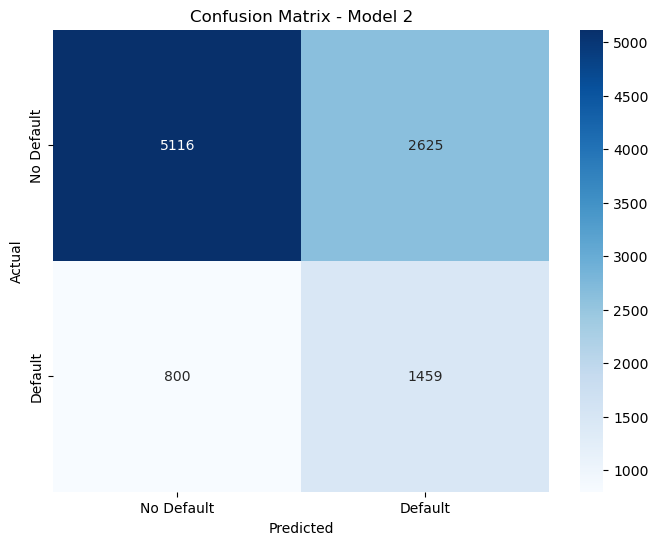

<Figure size 800x600 with 0 Axes>

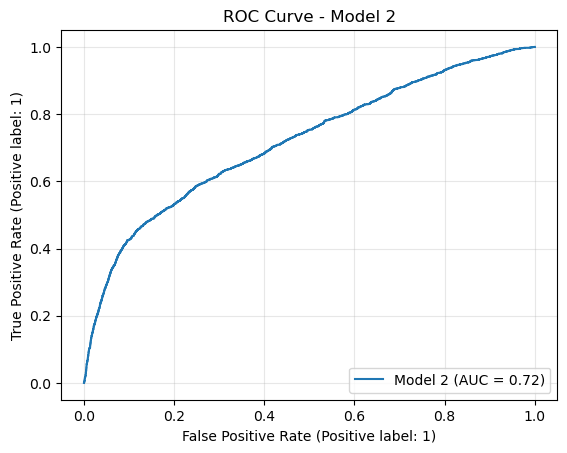

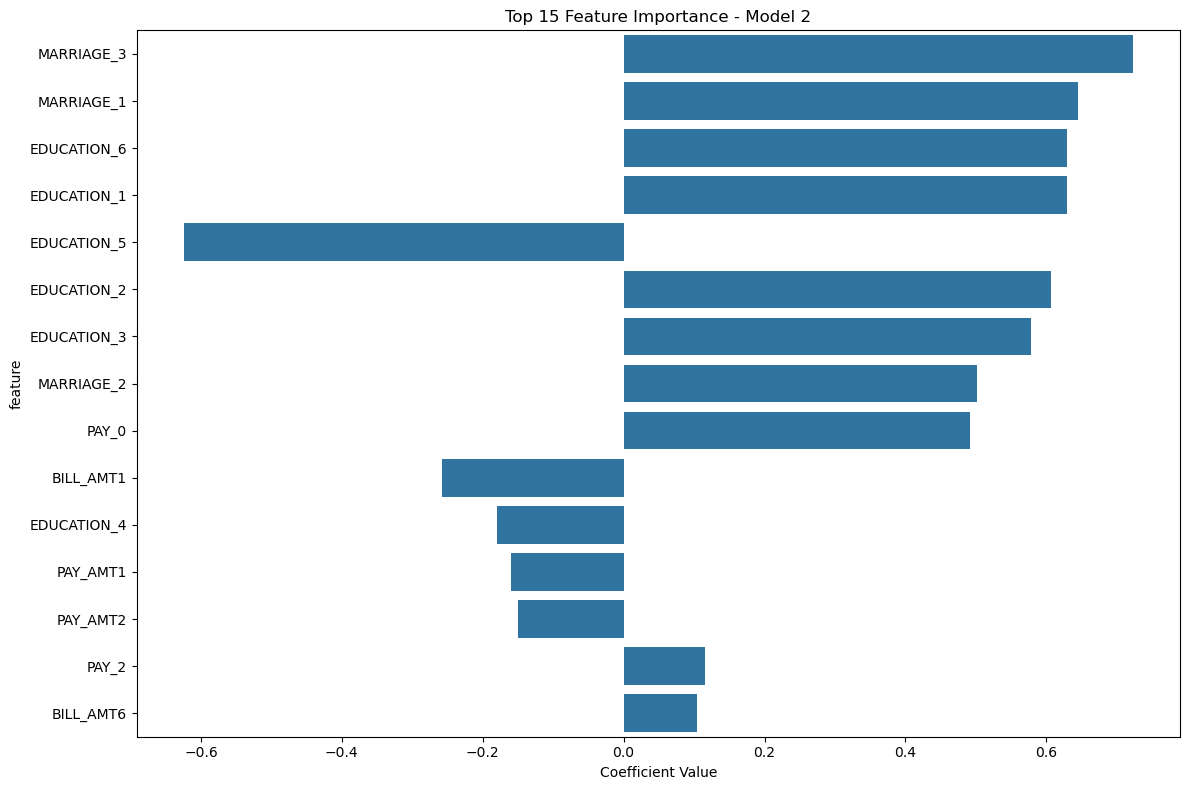

Top 15 Most Important Features for Model 2:
        feature  importance
29   MARRIAGE_3    0.722304
27   MARRIAGE_1    0.644371
26  EDUCATION_6    0.629438
21  EDUCATION_1    0.628972
25  EDUCATION_5   -0.623528
22  EDUCATION_2    0.606327
23  EDUCATION_3    0.578222
28   MARRIAGE_2    0.501730
2         PAY_0    0.491821
8     BILL_AMT1   -0.258237
24  EDUCATION_4   -0.179146
14     PAY_AMT1   -0.160077
15     PAY_AMT2   -0.149765
3         PAY_2    0.115308
13    BILL_AMT6    0.104490


In [40]:
# ============================================================
# Model 2: Last 20K train / First 10K test
# ============================================================
X_train_2 = X.iloc[-20000:]
y_train_2 = y.iloc[-20000:]
X_test_2 = X.iloc[:10000]
y_test_2 = y.iloc[:10000]

print(f"Training set size: {X_train_2.shape}")
print(f"Test set size: {X_test_2.shape}")

X_train_2_scaled = X_train_2.copy()
X_test_2_scaled = X_test_2.copy()
X_train_2_scaled[numerical_cols_for_scaling] = scaler.fit_transform(X_train_2[numerical_cols_for_scaling])
X_test_2_scaled[numerical_cols_for_scaling] = scaler.transform(X_test_2[numerical_cols_for_scaling])

# Train with class_weight='balanced'
logit_model_2 = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
logit_model_2.fit(X_train_2_scaled, y_train_2)

y_pred_2 = logit_model_2.predict(X_test_2_scaled)
y_prob_2 = logit_model_2.predict_proba(X_test_2_scaled)[:, 1]

print(f"\nModel 2 Accuracy: {accuracy_score(y_test_2, y_pred_2):.4f}")
print(f"Model 2 AUC-ROC:  {roc_auc_score(y_test_2, y_prob_2):.4f}")
print("\nClassification Report (focus on class 1 — defaults):")
print(classification_report(y_test_2, y_pred_2, target_names=['No Default', 'Default']))

cm_2 = confusion_matrix(y_test_2, y_pred_2)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix - Model 2')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test_2, y_prob_2, name="Model 2")
plt.title('ROC Curve - Model 2')
plt.grid(True, alpha=0.3)
plt.show()

feature_importance_2 = pd.DataFrame({
    'feature': X.columns,
    'importance': logit_model_2.coef_[0]
}).sort_values('importance', key=abs, ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance_2.head(15), x='importance', y='feature')
plt.title('Top 15 Feature Importance - Model 2')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print("Top 15 Most Important Features for Model 2:")
print(feature_importance_2.head(15))

## 9. Model comparison and evaluation

With both models trained and evaluated, the comparison below brings together all five metrics across both splits. The goal is not just to identify which model performs better numerically, but to understand what the differences (or similarities) reveal about the stability of credit default patterns across different time periods in the dataset.

In [41]:
# ============================================================
# Model Comparison (all metrics)
# ============================================================
# Comparing multiple metrics tells a richer story than accuracy alone.
# Recall: how many actual defaults did we catch?
# Precision: of predicted defaults, how many were real?
# F1: balance between recall and precision
# AUC-ROC: overall discrimination power across all thresholds
comparison = pd.DataFrame({
    'Model': ['First 20K Train / Next 10K Test', 'Last 20K Train / First 10K Test'],
    'Accuracy': [accuracy_score(y_test_1, y_pred_1),
                 accuracy_score(y_test_2, y_pred_2)],
    'Recall (Default)': [recall_score(y_test_1, y_pred_1),
                         recall_score(y_test_2, y_pred_2)],
    'Precision (Default)': [precision_score(y_test_1, y_pred_1),
                            precision_score(y_test_2, y_pred_2)],
    'F1 (Default)': [f1_score(y_test_1, y_pred_1),
                     f1_score(y_test_2, y_pred_2)],
    'AUC-ROC': [roc_auc_score(y_test_1, y_prob_1),
                roc_auc_score(y_test_2, y_prob_2)],
})

print("Model Comparison:")
print(comparison.round(4))

# Compare feature importance
feature_comparison = pd.merge(feature_importance_1, feature_importance_2, on='feature',
                            suffixes=('_model1', '_model2'))
feature_comparison['abs_importance_diff'] = (abs(feature_comparison['importance_model1'])
                                             - abs(feature_comparison['importance_model2']))

print("\nTop 10 Features with Largest Difference in Importance:")
top_diff_features = feature_comparison.reindex(
    feature_comparison['abs_importance_diff'].abs().nlargest(10).index)
print(top_diff_features[['feature', 'importance_model1', 'importance_model2', 'abs_importance_diff']])

Model Comparison:
                             Model  Accuracy  Recall (Default)  \
0  First 20K Train / Next 10K Test    0.7104            0.6261   
1  Last 20K Train / First 10K Test    0.6575            0.6459   

   Precision (Default)  F1 (Default)  AUC-ROC  
0               0.3804        0.4733   0.7365  
1               0.3572        0.4600   0.7182  

Top 10 Features with Largest Difference in Importance:
        feature  importance_model1  importance_model2  abs_importance_diff
0    MARRIAGE_1           1.333483           0.644371             0.689113
2    MARRIAGE_2           1.147239           0.501730             0.645509
6   EDUCATION_4          -0.686816          -0.179146             0.507670
1    MARRIAGE_3           1.183256           0.722304             0.460952
10  EDUCATION_5          -0.268711          -0.623528            -0.354817
8   EDUCATION_6          -0.327316           0.629438            -0.302122
3   EDUCATION_1           0.916085           0.628972     

### Key Observation

- **Model 1 outperforms Model 2 across all metrics:**

| Metric | Model 1 | Model 2 | Difference |
|--------|---------|---------|------------|
| Accuracy | 0.7104 | 0.6575 | +0.0529 |
| Recall (Default) | 0.63 | 0.65 | -0.02 |
| Precision (Default) | 0.38 | 0.36 | +0.02 |
| F1 (Default) | 0.47 | 0.46 | +0.01 |
| AUC-ROC | 0.7365 | 0.7182 | +0.0183 |

Model 1 leads on four out of five metrics. The only metric where Model 2 is marginally higher is Recall (0.65 vs 0.63), meaning Model 2 catches slightly more actual defaults, but at the cost of significantly more false alarms and lower overall discrimination power. The AUC-ROC gap of 0.018 is meaningful; Model 1 consistently ranks defaulters above non-defaulters more reliably across all classification thresholds.

- **What the accuracy gap reveals:**

Model 2's lower accuracy (0.6575 vs 0.7104) reflects that training on later data and testing on earlier observations introduces a temporal mismatch. This gap is consistent with mild data drift, meaning a gradual shift in customer behavior or credit risk dynamics across the dataset's time span.

- **Feature importance: consistency in direction, difference in magnitude:**

Both models agree on which features matter most: MARRIAGE and EDUCATION dummy variables dominate the top positions in both, followed by PAY_0, BILL_AMT1, and PAY_AMT1. This consistency confirms that the underlying relationship between these features and default risk is stable across time periods.

However, the magnitude of coefficients differs notably. In Model 1, MARRIAGE_1 has a coefficient of 1.333, more than double the 0.644 seen in Model 2 for the same feature. This compression of coefficients in Model 2 suggests that the later training period captures a more diffuse relationship between marital status and default risk.

PAY_0 remains consistently important in both models (0.487 and 0.492), reinforcing that recent payment status is the most stable and reliable behavioral signal for predicting default (independent of which time period the model learns from).

- **A note on the dominance of MARRIAGE and EDUCATION:**

The prominence of MARRIAGE and EDUCATION dummy variables at the top of the feature importance ranking is somewhat surprising given their weak linear correlations with default observed in the correlation matrix. This suggests that logistic regression is capturing interaction effects between these demographic variables and other features that are not visible in pairwise correlations alone. It also highlights a limitation worth acknowledging: a high coefficient does not always mean that variable is truly predictive. When a category has very few observations (like EDUCATION=6 with only 51 cases) the model has limited data to learn from, and the resulting coefficient may be large simply due to statistical noise rather than a real pattern.

## 10. Business Conclusion

Model 1 is the preferred model for deployment. With an AUC-ROC of 0.737, it correctly identifies 63% of actual defaults while maintaining reasonable precision. In practical terms, for every 100 customers the model flags as high-risk, 38 will actually default, a meaningful signal for credit risk management, though not sufficient as a standalone decision tool. The model performs best as a risk-scoring mechanism to prioritize accounts for further review, rather than as a binary approve/reject classifier.

**Which metric matters most for this problem?**

Of the five metrics evaluated, AUC-ROC is the most informative for credit risk because it measures the model's ability to distinguish defaulters from non-defaulters across all possible thresholds, independent of any specific classification cutoff. Accuracy is misleading given the class imbalance. Recall and Precision reflect a trade-off that depends on business context. F1 balances both but collapses that trade-off into a single number that obscures the decision.

AUC-ROC of 0.737 in Model 1 means that given a random defaulter and a random non-defaulter, the model ranks the defaulter as higher risk 73.7% of the time. That is the most honest summary of what this model can and cannot do.